# Customer Churn Prediction Platform

## Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to explore the IBM Telco Customer Churn dataset, understand the available features, identify data quality issues, and gain business insights before building predictive models.


In [53]:
import pandas as pd
import numpy as np
import sys
import os

sys.path.append(os.path.abspath("../src"))

from data.preprocess import preprocess_data

import matplotlib.pyplot as plt

# Display all columns when viewing dataframes
pd.set_option("display.max_columns", None)

# Load dataset
df = preprocess_data(
    "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

# Display first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [54]:
def plot_churn_rate(feature):
    """
    Display churn counts and churn percentages for a categorical feature.
    """
    import matplotlib.pyplot as plt

    churn_counts = pd.crosstab(df[feature], df["Churn"])

    churn_counts.plot(
        kind="bar",
        figsize=(8, 5)
    )

    plt.title(f"Churn by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=45)
    plt.legend(title="Churn")
    plt.tight_layout()
    plt.show()

    churn_rate = (
        pd.crosstab(df[feature], df["Churn"], normalize="index") * 100
    )

    display(churn_rate.round(2))

## Dataset Overview

Before performing any analysis, it is important to understand the size, structure, and data types within the dataset.


In [2]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 7043
Columns: 21


## Column Information

Understanding each feature helps determine which variables may influence customer churn.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Missing Values

Missing data can negatively affect machine learning models. We check each feature before any preprocessing.


In [4]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

## Statistical Summary

Summary statistics provide an overview of the numerical variables in the dataset.


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Target Variable

The target variable is **Churn**, indicating whether a customer left the company.

Understanding the class distribution is important because machine learning models can become biased if one class heavily outweighs the other.


In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

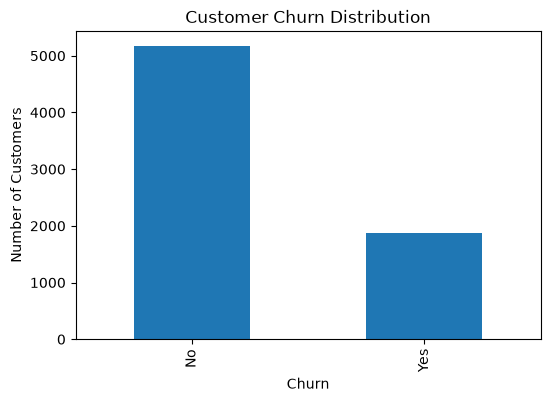

In [8]:
df["Churn"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

The majority of customers did not churn.

This indicates that customer retention is generally good, but the company still loses a significant number of customers.

Predicting these customers before they leave could help the business reduce revenue loss through targeted retention strategies.


## Duplicate Records

Duplicate records can introduce bias into the analysis and negatively impact model performance. Before continuing, we verify whether duplicate customer records exist.

In [9]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


## Unique Values

Understanding the number of unique values in each feature helps distinguish categorical variables from continuous variables and highlights potential identifier columns.

In [10]:
unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
})

unique_values

,Column,Unique Values
0,customerID,7043
1,gender,2
2,SeniorCitizen,2
3,Partner,2
4,Dependents,2
5,tenure,73
6,PhoneService,2
7,MultipleLines,3
8,InternetService,3
9,OnlineSecurity,3


## Data Types

The following table summarises the data type of each feature in the dataset.

In [11]:
dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

dtype_summary

,Column,Data Type
0,customerID,str
1,gender,str
2,SeniorCitizen,int64
3,Partner,str
4,Dependents,str
5,tenure,int64
6,PhoneService,str
7,MultipleLines,str
8,InternetService,str
9,OnlineSecurity,str


# Data Quality Investigation

## TotalCharges

Although the dataset appears to contain no missing values, the `TotalCharges` column is stored as an object rather than a numeric data type.

This section investigates the cause of this issue before data preprocessing begins.

In [12]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [13]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

In [14]:
pd.to_numeric(df["TotalCharges"])

ValueError: Unable to parse string " " at position 488

In [15]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [16]:
blank_totalcharges = (df["TotalCharges"] == " ").sum()

print(f"Blank TotalCharges values: {blank_totalcharges}")

Blank TotalCharges values: 11


### Business Insight

Although no formal missing values were detected using `isnull()`, the `TotalCharges` feature contains blank strings.

These blank values prevent the column from being treated as numerical data and must be cleaned before building machine learning models.

This highlights the importance of checking for hidden data quality issues rather than relying solely on automated missing value detection.

## Cleaning TotalCharges

The `TotalCharges` column contains blank strings that prevent it from being treated as numerical data.

These values are first converted to `NaN`, after which an appropriate imputation strategy is applied.

In [21]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [22]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [23]:
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [24]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [25]:
print(df["TotalCharges"].dtype)

float64


In [26]:
print(df["TotalCharges"].isna().sum())

0


In [27]:
df["TotalCharges"].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

### Business Insight

The hidden blank values in the `TotalCharges` column were successfully identified, converted into proper missing values, and replaced with `0` after investigation.

Because these customers had zero months of tenure, assigning a total charge of zero accurately reflects their billing history while preserving valid customer records.

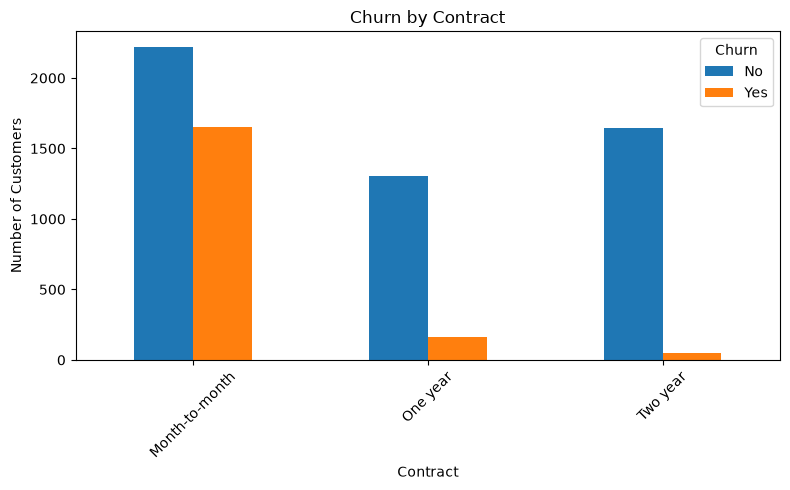

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [29]:
plot_churn_rate("Contract")

### Business Insight - Contract Type

Customers on month-to-month contracts experience substantially higher churn rates than customers on one-year or two-year contracts.

Longer-term contracts appear to improve customer retention, suggesting that encouraging customers to commit to longer contracts may reduce churn.

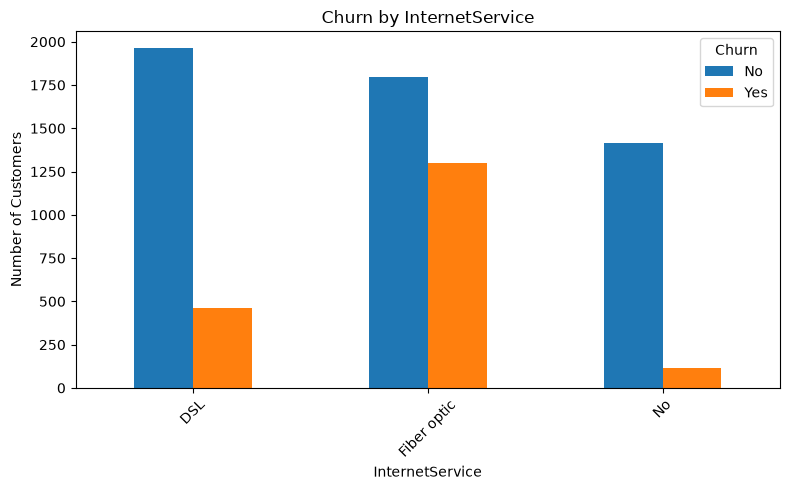

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


In [30]:
plot_churn_rate("InternetService")

### Business Insight - Internet Service

Customers using fibre optic internet show higher churn rates than customers using DSL or those without internet service.

This may indicate differences in pricing, customer expectations, service quality, or customer demographics, which should be investigated further.

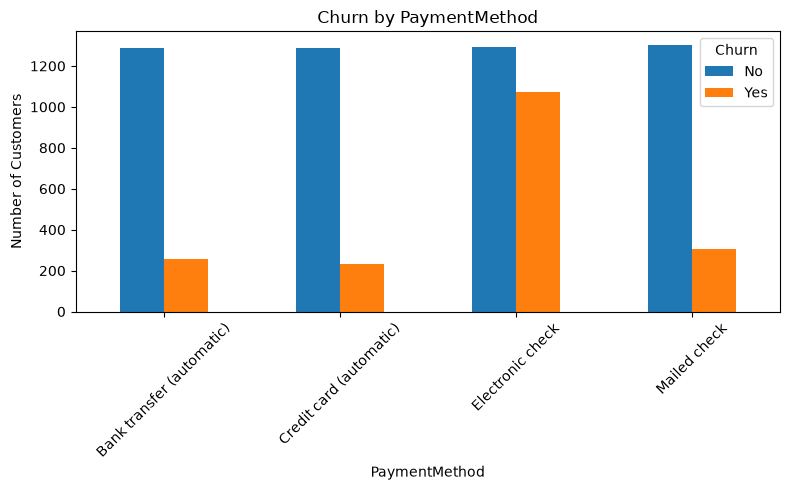

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


In [31]:
plot_churn_rate("PaymentMethod")

### Business Insight - Payment Method

Customers paying by electronic check exhibit the highest churn rate among all payment methods.

This relationship does not necessarily imply causation, but it suggests that payment method may be associated with customer behaviour and should be explored further alongside other variables.

# Numerical Feature Analysis

This section explores the numerical variables in the dataset to better understand customer behaviour and identify patterns related to churn.

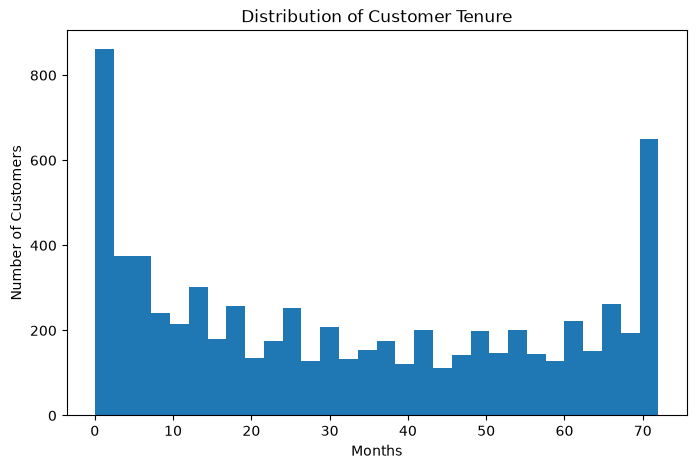

In [32]:
plt.figure(figsize=(8,5))

plt.hist(df["tenure"], bins=30)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Months")
plt.ylabel("Number of Customers")

plt.show()

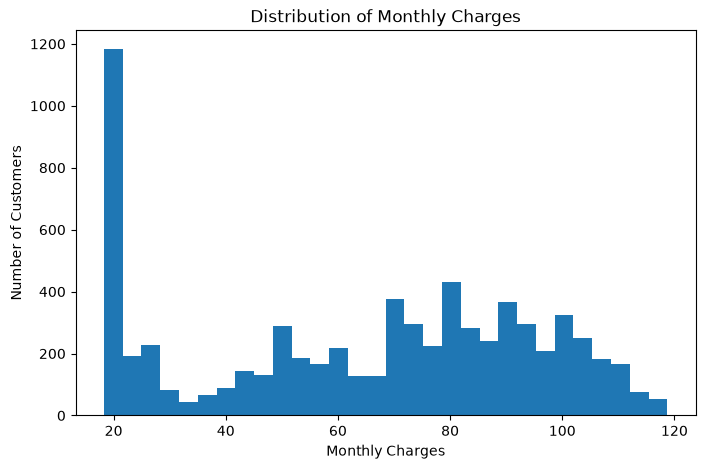

In [33]:
plt.figure(figsize=(8,5))

plt.hist(df["MonthlyCharges"], bins=30)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

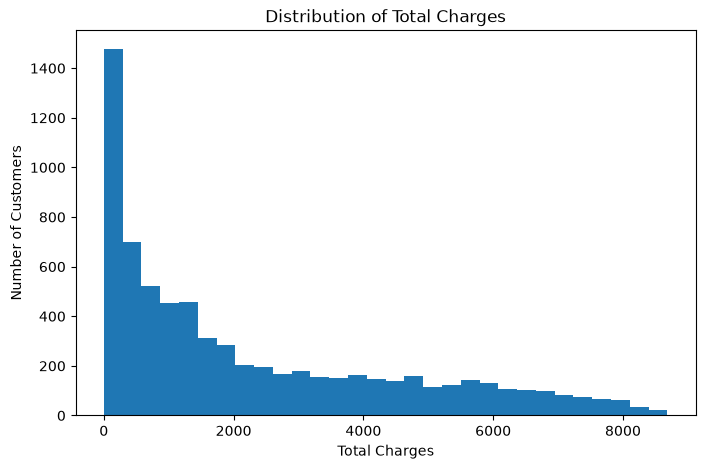

In [34]:
plt.figure(figsize=(8,5))

plt.hist(df["TotalCharges"], bins=30)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

<Figure size 800x500 with 0 Axes>

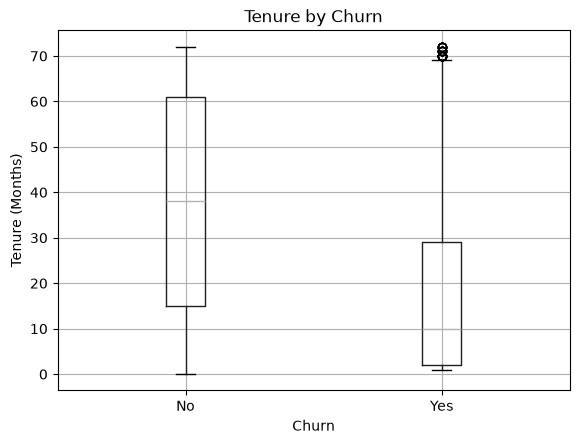

In [35]:
plt.figure(figsize=(8,5))

df.boxplot(column="tenure", by="Churn")

plt.title("Tenure by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

<Figure size 800x500 with 0 Axes>

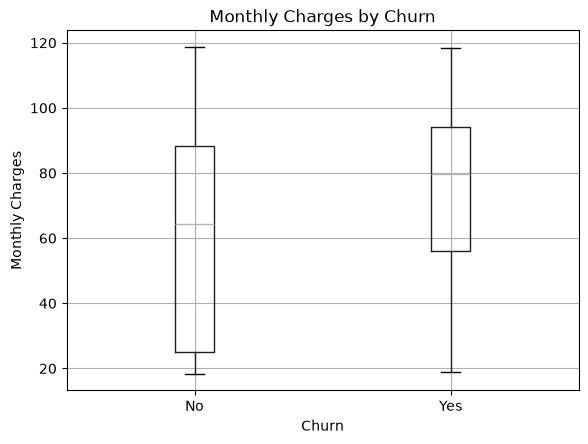

In [36]:
plt.figure(figsize=(8,5))

df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

<Figure size 800x500 with 0 Axes>

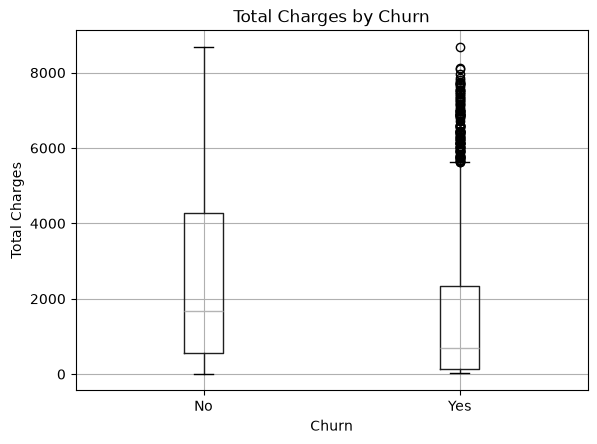

In [37]:
plt.figure(figsize=(8,5))

df.boxplot(column="TotalCharges", by="Churn")

plt.title("Total Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

### Business Insight - Tenure

Customers who churn generally have much shorter tenure than customers who remain with the company.

This suggests that the early stages of the customer lifecycle are critical for retention, and businesses should prioritise onboarding and early customer engagement.

### Business Insight - Monthly Charges

Customers who churn tend to have slightly higher monthly charges than customers who remain.

This may indicate that pricing, perceived value, or service expectations influence customer retention.

### Business Insight - Total Charges

Customers who churn generally have lower total charges.

This is consistent with their shorter tenure, as they have had less time to accumulate billing history.

In [38]:
df_encoded = df.copy()

In [39]:
df_encoded["Churn"] = df_encoded["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [40]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in df_encoded.select_dtypes(include="object").columns:
    df_encoded[column] = encoder.fit_transform(df_encoded[column])

C:\Users\jonat\AppData\Local\Temp\ipykernel_17624\3274047152.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df_encoded.select_dtypes(include="object").columns:


In [41]:
correlation_matrix = df_encoded.corr()

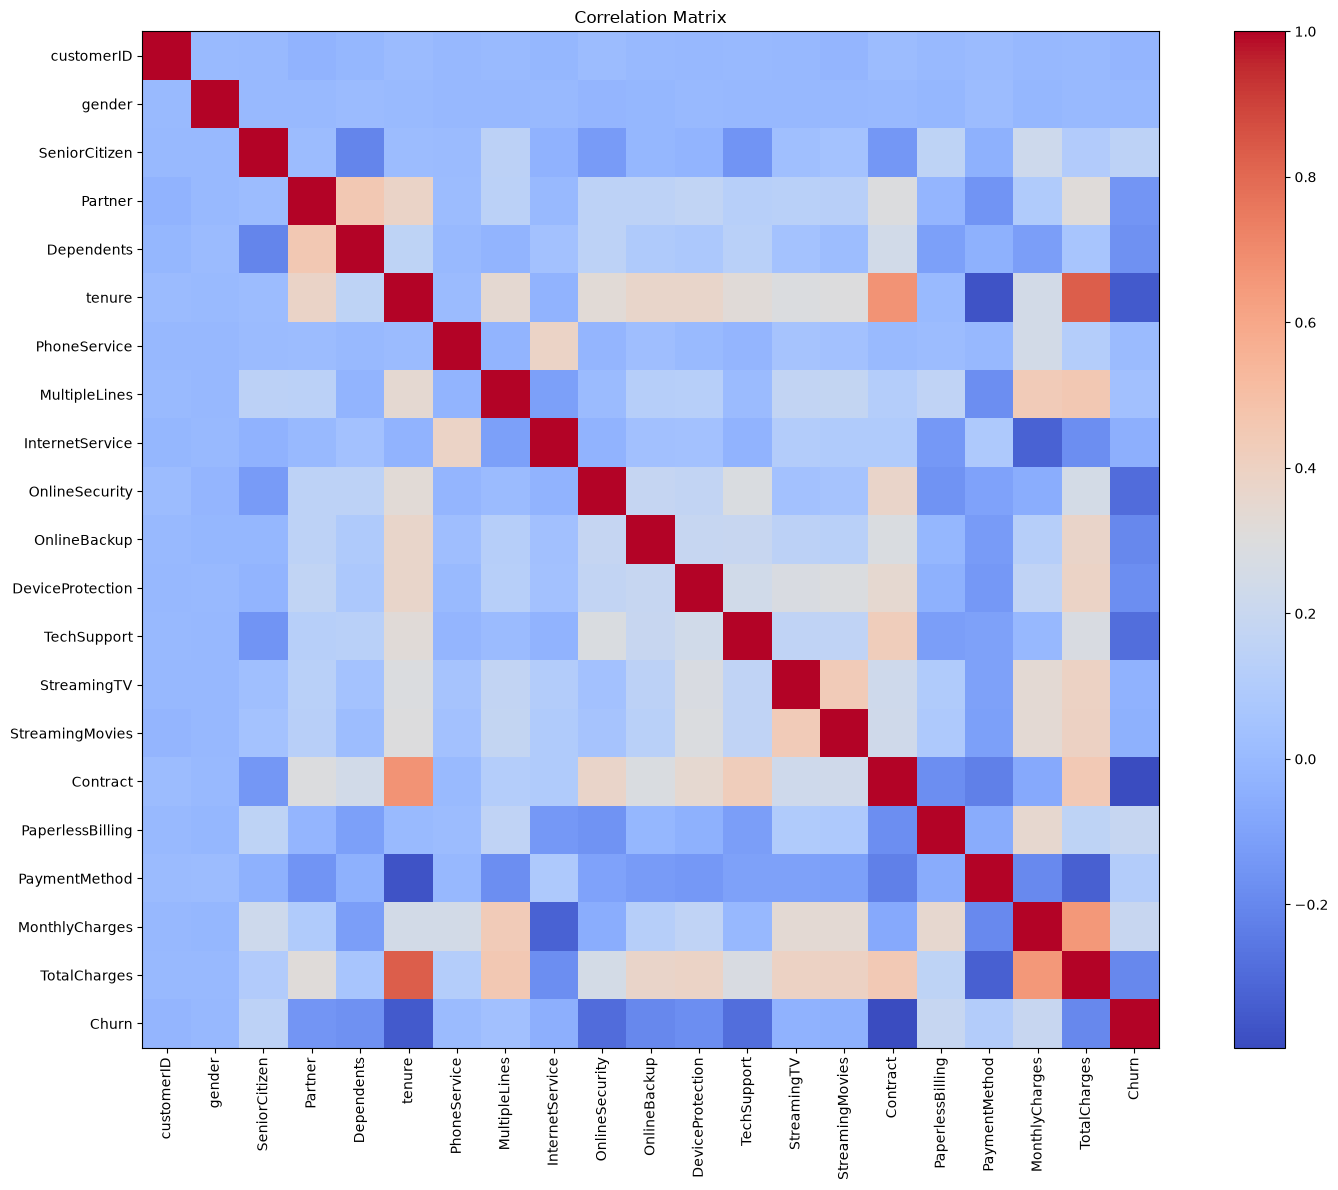

In [42]:
plt.figure(figsize=(16,12))

plt.imshow(correlation_matrix, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [43]:
correlation_matrix["Churn"].sort_values(ascending=False)

Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
PhoneService        0.011942
gender             -0.008612
customerID         -0.017447
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TotalCharges       -0.198324
TechSupport        -0.282492
OnlineSecurity     -0.289309
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64

In [55]:
churn_corr = correlation_matrix["Churn"].sort_values(
    key=abs,
    ascending=False
)

churn_corr

Churn               1.000000
Contract           -0.396713
tenure             -0.352229
OnlineSecurity     -0.289309
TechSupport        -0.282492
TotalCharges       -0.198324
OnlineBackup       -0.195525
MonthlyCharges      0.193356
PaperlessBilling    0.191825
DeviceProtection   -0.178134
Dependents         -0.164221
SeniorCitizen       0.150889
Partner            -0.150448
PaymentMethod       0.107062
InternetService    -0.047291
StreamingMovies    -0.038492
MultipleLines       0.038037
StreamingTV        -0.036581
customerID         -0.017447
PhoneService        0.011942
gender             -0.008612
Name: Churn, dtype: float64

In [56]:
churn_corr = churn_corr.drop("Churn")

churn_corr.head(10)

Contract           -0.396713
tenure             -0.352229
OnlineSecurity     -0.289309
TechSupport        -0.282492
TotalCharges       -0.198324
OnlineBackup       -0.195525
MonthlyCharges      0.193356
PaperlessBilling    0.191825
DeviceProtection   -0.178134
Dependents         -0.164221
Name: Churn, dtype: float64

## Correlation Analysis

Correlation analysis provides an initial indication of which variables are most strongly associated with customer churn.

While correlation does not imply causation, it helps identify potentially important predictors that should be explored further during model development.

# Key Predictors of Churn

Based on the exploratory data analysis, several variables appear to have strong relationships with customer churn.

These observations will guide feature engineering and model development in the next phase of the project.

## Key Findings

- Customers on month-to-month contracts have the highest churn rate.
- Customers with shorter tenure are significantly more likely to churn.
- Fibre optic customers experience higher churn than DSL customers.
- Customers paying by electronic check exhibit elevated churn.
- Customers with higher monthly charges tend to churn more frequently.
- Longer contract durations are associated with improved customer retention.

# Business Recommendations

Based on the exploratory analysis, the following recommendations may help improve customer retention:

1. Focus retention campaigns on customers within their first year.
2. Encourage customers to move from month-to-month contracts to longer-term agreements.
3. Investigate the customer experience associated with fibre optic services.
4. Analyse why customers using electronic check payments are more likely to leave.
5. Review pricing strategies for customers with high monthly charges.

# Conclusion

The exploratory data analysis successfully identified important customer behaviour patterns and uncovered several data quality issues that required preprocessing.

The analysis suggests that contract type, tenure, monthly charges, internet service, and payment method are all likely to contribute to customer churn prediction.

These findings provide a strong foundation for feature engineering and machine learning model development.